# **1. Environment Setup & Library Imports **
We begin by importing all required libraries for data handling, image processing, deep learning, and evaluation. All imports are consolidated here to keep the notebook clean.

In [6]:

import os
import sys
import platform
import warnings
warnings.filterwarnings('ignore')

# Data handling
import numpy as np
import pandas as pd

# Image processing
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

# Deep learning — TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten,
    Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model

# Display
from IPython.display import Image as IPImage, display

print("All libraries imported successfully.")
print(f"   Python     : {sys.version.split()[0]}")
print(f"   TensorFlow : {tf.__version__}")
print(f"   NumPy      : {np.__version__}")
print(f"   Pandas     : {pd.__version__}")

All libraries imported successfully.
   Python     : 3.12.13
   TensorFlow : 2.19.0
   NumPy      : 2.4.6
   Pandas     : 2.3.3


In [7]:
# ----- Python Library Versions Table -----
import sklearn, matplotlib

libraries_df = pd.DataFrame({
    "Library"  : ["Python", "TensorFlow", "Pandas", "NumPy", "Scikit-learn", "Matplotlib", "OpenCV", "Seaborn"],
    "Version"  : [
        sys.version.split()[0],
        tf.__version__,
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        cv2.__version__,
        sns.__version__
    ]
})

print("Library Versions:")
display(libraries_df)

Library Versions:


,Library,Version
0,Python,3.12.13
1,TensorFlow,2.19.0
2,Pandas,2.3.3
3,NumPy,2.4.6
4,Scikit-learn,1.6.1
5,Matplotlib,3.10.0
6,OpenCV,4.13.0
7,Seaborn,0.13.2


In [8]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# *2. Dataset Description***
The **Fashion Product Images Dataset** (by Param Aggarwal on Kaggle) is a large-scale retail fashion dataset. It contains high-resolution product images across many clothing and accessory categories.

We use **7 selected classes** for this classification task.

In [9]:

dataset_info = pd.DataFrame({
    "Attribute"   : [
        "Dataset Name",
        "Source",
        "Total Images (full dataset)",
        "Classes Used",
        "Number of Classes",
        "Image Format",
        "Image Size (original)",
        "Image Size (resized)",
        "Task Type",
        "Samples per Class (max, balanced)"
    ],
    "Details" : [
        "Fashion Product Images Dataset",
        "Kaggle — paramaggarwal",
        "~44,000 images",
        "Shirts, Tshirts, Jeans, Wallet, Casual Shoes, Watches, Tops",
        "7",
        "JPEG (.jpg)",
        "Variable (80×60 to 400×300 approx.)",
        "128 × 128 × 3 (RGB)",
        "Multi-class Image Classification",
        "700 images per class (4,900 total)"
    ]
})

print("Dataset Description:")
display(dataset_info)

Dataset Description:


,Attribute,Details
0,Dataset Name,Fashion Product Images Dataset
1,Source,Kaggle — paramaggarwal
2,Total Images (full dataset),"~44,000 images"
3,Classes Used,"Shirts, Tshirts, Jeans, Wallet, Casual Shoes, ..."
4,Number of Classes,7
5,Image Format,JPEG (.jpg)
6,Image Size (original),Variable (80×60 to 400×300 approx.)
7,Image Size (resized),128 × 128 × 3 (RGB)
8,Task Type,Multi-class Image Classification
9,"Samples per Class (max, balanced)","700 images per class (4,900 total)"


# *3. Dataset Loading***
We load the `styles.csv` metadata file which maps each product ID to its attributes (category, colour, gender, etc.). The image files are stored separately as `<id>.jpg`.

In [10]:
CSV_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/styles.csv"

df = pd.read_csv(CSV_PATH, on_bad_lines="skip")

print("Dataset loaded successfully.")
print(f"   Shape       : {df.shape}")
print(f"   Columns     : {list(df.columns)}")
print()
df.head()

Dataset loaded successfully.
   Shape       : (44424, 10)
   Columns     : ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']



,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


# *4. Data Preprocessing***
### Steps:
1. **Filter** to 7 target article types
2. **Check and remove** null values
3. **Build image paths** from product IDs
4. **Verify image existence** on disk
5. **Balance** classes (max 700 samples each)
6. **Encode labels** numerically

In [11]:
#FILTER TO 7 TARGET CLASSES

TOP_CLASSES = ["Shirts", "Tshirts", "Jeans", "Handbags", "Casual Shoes", "Watches", "Tops"]

df = df[df["articleType"].isin(TOP_CLASSES)].copy()

print(f"Filtered to {len(TOP_CLASSES)} classes.")
print(f"   Shape after filtering : {df.shape}")
print()
print("Class counts after filtering:")
print(df["articleType"].value_counts())

Filtered to 7 classes.
   Shape after filtering : (19801, 10)

Class counts after filtering:
articleType
Tshirts         7067
Shirts          3217
Casual Shoes    2845
Watches         2542
Tops            1762
Handbags        1759
Jeans            609
Name: count, dtype: int64


In [12]:
#CHECK AND REMOVE NULL VALUES

print("Null values per column:")
print(df.isnull().sum())

df = df.dropna()
print(f"\n Null values removed. Shape: {df.shape}")

Null values per column:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            6
season                1
year                  1
usage                 3
productDisplayName    0
dtype: int64

 Null values removed. Shape: (19791, 10)


In [13]:
#BUILD IMAGE PATHS

IMAGE_DIR = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

df["image_path"] = IMAGE_DIR + "/" + df["id"].astype(str) + ".jpg"

print("Image paths constructed.")
df[["id", "articleType", "image_path"]].head()

Image paths constructed.


,id,articleType,image_path
0,15970,Shirts,/kaggle/input/datasets/paramaggarwal/fashion-p...
1,39386,Jeans,/kaggle/input/datasets/paramaggarwal/fashion-p...
2,59263,Watches,/kaggle/input/datasets/paramaggarwal/fashion-p...
4,53759,Tshirts,/kaggle/input/datasets/paramaggarwal/fashion-p...
5,1855,Tshirts,/kaggle/input/datasets/paramaggarwal/fashion-p...


In [14]:
#VERIFY IMAGE EXISTENCE ON DISK

df["exists"] = df["image_path"].apply(os.path.exists)

print("Image existence check:")
print(df["exists"].value_counts())

# Keep only rows where image file exists
df = df[df["exists"]].copy()
print(f"\n Shape after removing missing images: {df.shape}")

Image existence check:
exists
True     19787
False        4
Name: count, dtype: int64

 Shape after removing missing images: (19787, 12)


In [15]:
#BALANCE CLASSES (max 700 per class)

MAX_PER_CLASS = 700

balanced_df = (
    df.groupby("articleType")
      .apply(lambda x: x.sample(n=min(len(x), MAX_PER_CLASS), random_state=42))
      .reset_index(drop=True)
)

print(" Dataset balanced.")
print(f"   Balanced shape : {balanced_df.shape}")
print()
print("Samples per class:")
print(balanced_df["articleType"].value_counts())

# Save the balanced CSV for reference
balanced_df.to_csv("fashion_top7_balanced.csv", index=False)
print(f"\n Balanced CSV saved as 'fashion_top7_balanced.csv'")

 Dataset balanced.
   Balanced shape : (4802, 12)

Samples per class:
articleType
Casual Shoes    700
Handbags        700
Shirts          700
Tshirts         700
Tops            700
Watches         700
Jeans           602
Name: count, dtype: int64

 Balanced CSV saved as 'fashion_top7_balanced.csv'


# *5. Exploratory Data Analysis (EDA)***
Before building any model, we visualise the **class distribution** to understand the data balance.

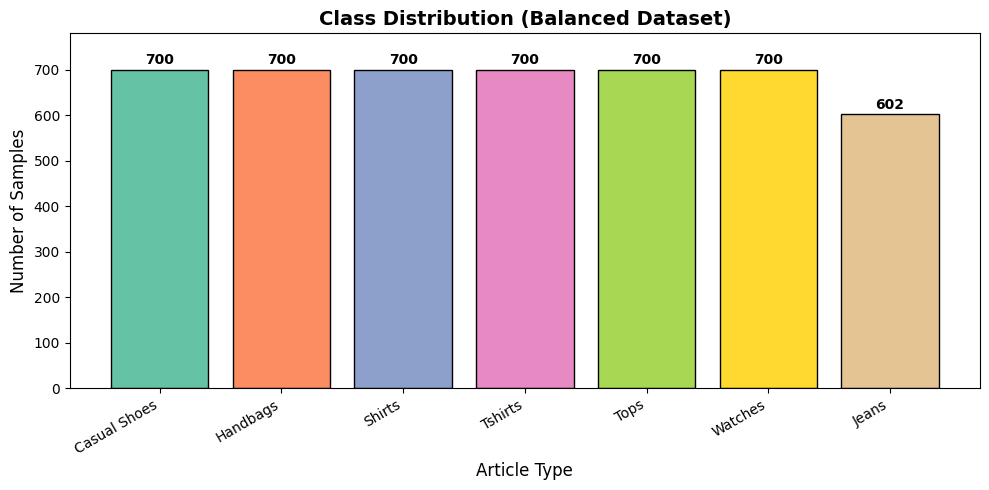

Class distribution chart saved as 'class_distribution.png'


In [16]:
#CLASS DISTRIBUTION BAR CHART

class_counts = balanced_df["articleType"].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(class_counts.index, class_counts.values,
               color=plt.cm.Set2.colors[:len(class_counts)], edgecolor='black')

# Annotate each bar with the count
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 5,
             str(count), ha='center', va='bottom', fontweight='bold')

plt.title("Class Distribution (Balanced Dataset)", fontsize=14, fontweight='bold')
plt.xlabel("Article Type", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.ylim(0, class_counts.max() + 80)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

print("Class distribution chart saved as 'class_distribution.png'")

# *6. Image Loading, Resizing & Normalization***
Each image is:
- Loaded from disk using **OpenCV**
- Converted from **BGR → RGB** (OpenCV reads in BGR by default)
- **Resized to 128×128** pixels (uniform input size for the CNN)
- **Normalized** to the range [0, 1] by dividing pixel values by 255

In [17]:
#LOAD, RESIZE, AND NORMALIZE ALL IMAGES

IMG_SIZE = 128
BASE_PATH = "/kaggle/input/datasets/paramaggarwal/fashion-product-images-dataset/fashion-dataset/images"

X = []
y = []
failed = 0

for _, row in balanced_df.iterrows():
    img_path = row["image_path"]
    img = cv2.imread(img_path)

    if img is None:
        failed += 1
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)       # BGR → RGB
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))        # Resize to 128×128

    X.append(img)
    y.append(row["articleType"])

X = np.array(X)
y = np.array(y)

print(f" Images loaded successfully.")
print(f"   X shape  : {X.shape}  (samples, height, width, channels)")
print(f"   y shape  : {y.shape}")
print(f"   Failed   : {failed}")

 Images loaded successfully.
   X shape  : (4802, 128, 128, 3)  (samples, height, width, channels)
   y shape  : (4802,)
   Failed   : 0


In [18]:
#PIXEL NORMALIZATION  [0, 255] → [0.0, 1.0]


X = X.astype("float32") / 255.0

print("Normalization complete.")
print(f"   Min pixel value : {X.min():.4f}")
print(f"   Max pixel value : {X.max():.4f}")

Normalization complete.
   Min pixel value : 0.0000
   Max pixel value : 1.0000


# *7. Label Encoding & Train / Validation / Test Split***
String class names are converted to integers (0–6) using `LabelEncoder`.

In [19]:
# LABEL ENCODING

le = LabelEncoder()
le.fit(TOP_CLASSES)           # ← fit on the fixed list, not on df
y_encoded = le.transform(y)

print("Labels encoded.")
print(f"   Classes : {list(le.classes_)}")

label_map = pd.DataFrame({
    "Class Name"    : le.classes_,
    "Encoded Label" : range(len(le.classes_))
})
display(label_map)

Labels encoded.
   Classes : [np.str_('Casual Shoes'), np.str_('Handbags'), np.str_('Jeans'), np.str_('Shirts'), np.str_('Tops'), np.str_('Tshirts'), np.str_('Watches')]


,Class Name,Encoded Label
0,Casual Shoes,0
1,Handbags,1
2,Jeans,2
3,Shirts,3
4,Tops,4
5,Tshirts,5
6,Watches,6


In [20]:
# TRAIN / VALIDATION / TEST SPLIT  (70 / 15 / 15)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Data split complete.")
print(f"   Train      : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Validation : {X_val.shape[0]} samples  ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"   Test       : {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.1f}%)")

Data split complete.
   Train      : 3361 samples  (70.0%)
   Validation : 720 samples  (15.0%)
   Test       : 721 samples  (15.0%)


# *8. Sample Images Visualization***

In [21]:
print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))

print("\ny_train distribution:")
for i, cls in enumerate(le.classes_):
    count = np.sum(y_train == i)
    print(f"{i}: {cls} -> {count}")

Classes: ['Casual Shoes' 'Handbags' 'Jeans' 'Shirts' 'Tops' 'Tshirts' 'Watches']
Number of classes: 7

y_train distribution:
0: Casual Shoes -> 490
1: Handbags -> 490
2: Jeans -> 421
3: Shirts -> 490
4: Tops -> 490
5: Tshirts -> 490
6: Watches -> 490


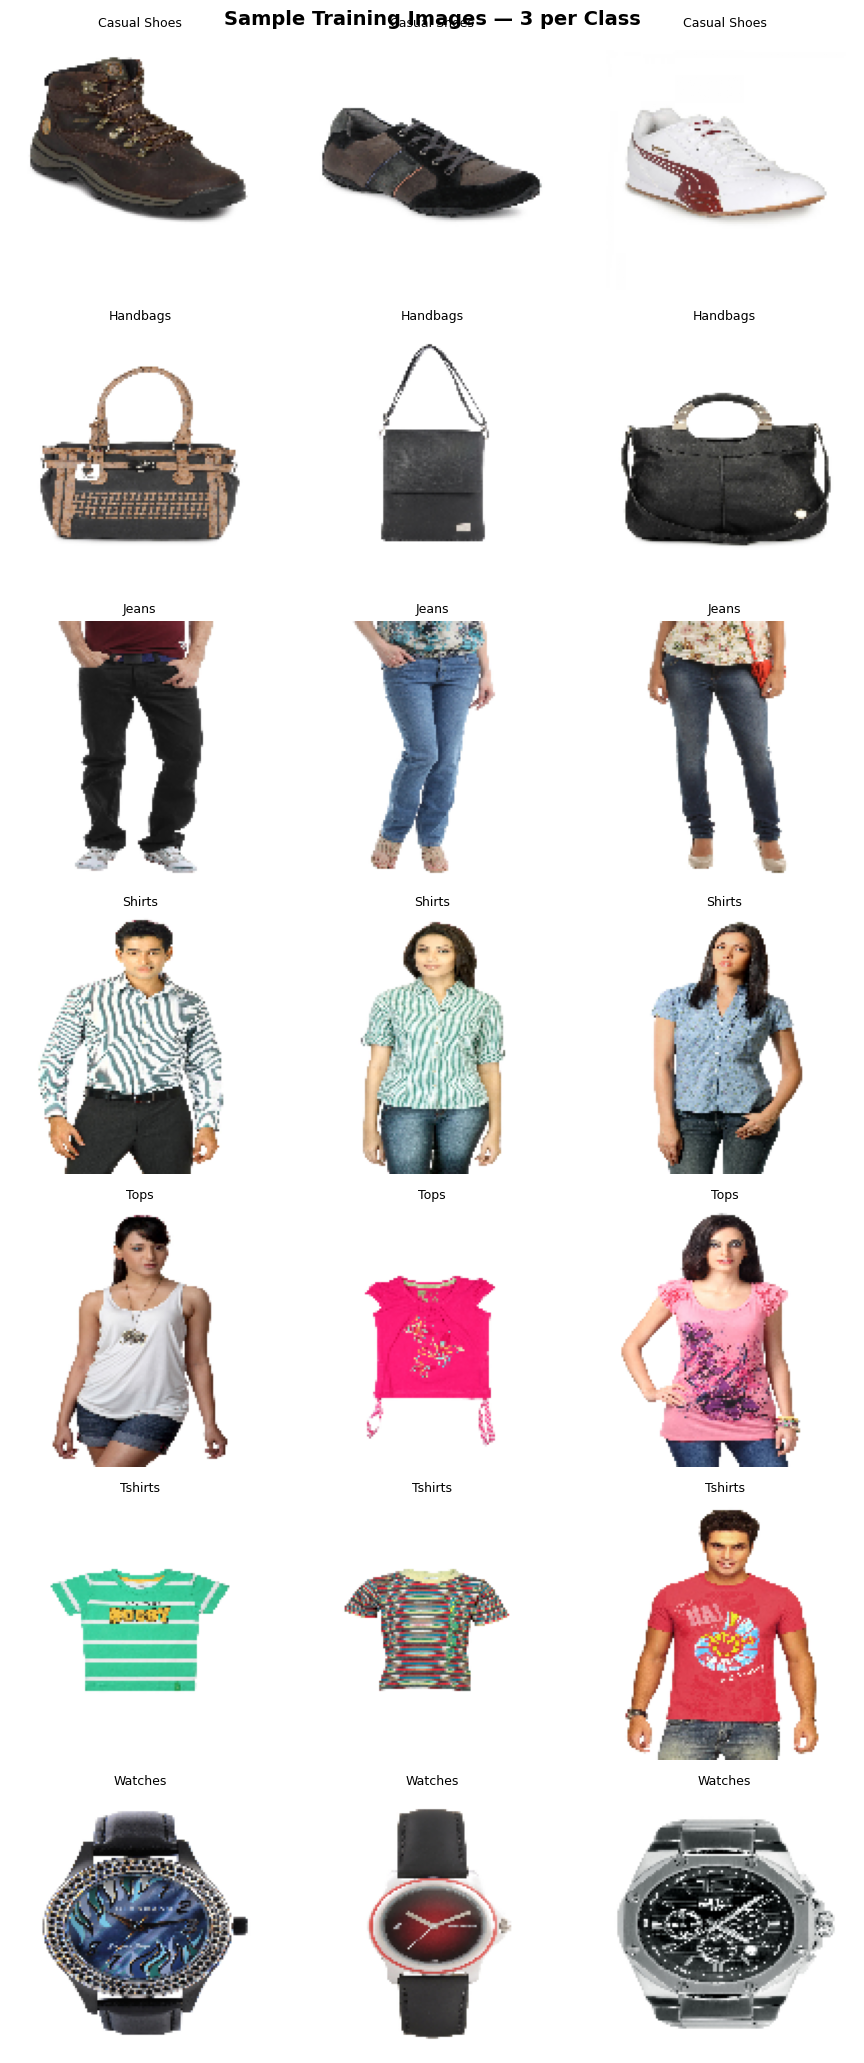

Sample images saved as 'sample_images.png'


In [22]:
# DISPLAY SAMPLE TRAINING IMAGES (3 per class)

n_classes = len(le.classes_)
samples_per_class = 3

fig, axes = plt.subplots(n_classes, samples_per_class,
                         figsize=(samples_per_class * 3, n_classes * 3))
fig.suptitle("Sample Training Images — 3 per Class", fontsize=14, fontweight='bold')

for class_idx, class_name in enumerate(le.classes_):
    idxs = np.where(y_train == class_idx)[0]
    chosen = np.random.choice(idxs, samples_per_class, replace=False)
    for col, img_idx in enumerate(chosen):
        ax = axes[class_idx][col]
        ax.imshow(X_train[img_idx])
        ax.set_title(class_name, fontsize=9)
        ax.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png", dpi=150, bbox_inches='tight')
plt.show()

print("Sample images saved as 'sample_images.png'")

# *9. Data Augmentation***
Data augmentation artificially increases training diversity by applying random geometric transformations to images. This helps the model **generalise better** and reduces **overfitting**.

In [23]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

datagen.fit(X_train)

print("Data augmentation pipeline configured.")

Data augmentation pipeline configured.


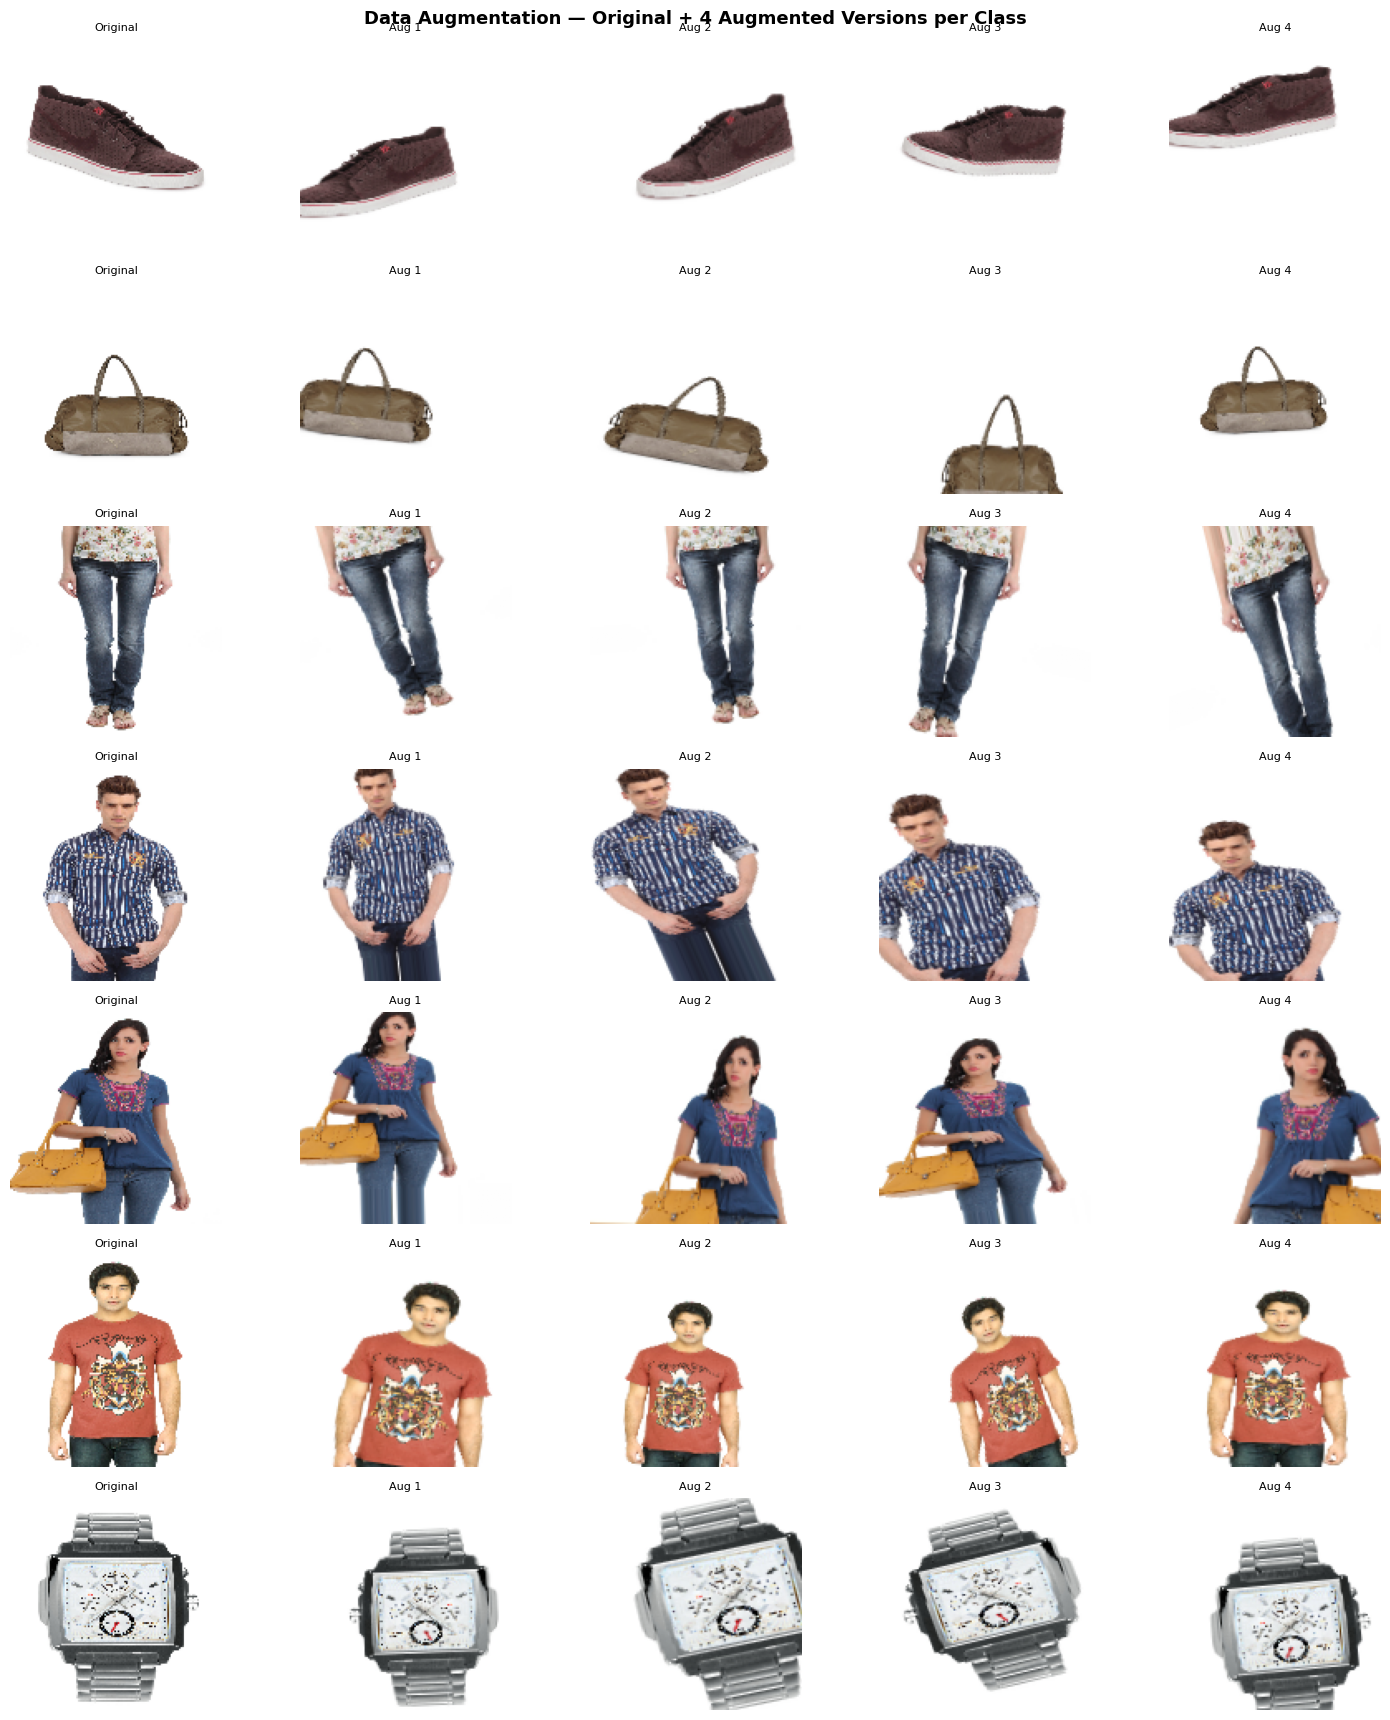

Augmented samples saved as 'augmented_samples.png'


In [24]:
fig, axes = plt.subplots(n_classes, 5, figsize=(15, n_classes * 2.5))
fig.suptitle("Data Augmentation — Original + 4 Augmented Versions per Class",
             fontsize=13, fontweight='bold')

for class_idx, class_name in enumerate(le.classes_):
    idxs = np.where(y_train == class_idx)[0]
    sample_img = X_train[idxs[0]][np.newaxis, ...]  # shape (1, 128, 128, 3)

    # Original
    axes[class_idx][0].imshow(X_train[idxs[0]])
    axes[class_idx][0].set_title("Original", fontsize=8)
    axes[class_idx][0].axis("off")
    axes[class_idx][0].set_ylabel(class_name, rotation=90, fontsize=8, labelpad=40)

    # 4 augmented
    aug_iter = datagen.flow(sample_img, batch_size=1)
    for col in range(1, 5):
        aug_img = next(aug_iter)[0]
        axes[class_idx][col].imshow(np.clip(aug_img, 0, 1))
        axes[class_idx][col].set_title(f"Aug {col}", fontsize=8)
        axes[class_idx][col].axis("off")

plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=150, bbox_inches='tight')
plt.show()

print("Augmented samples saved as 'augmented_samples.png'")

# *10. CNN Model Development & Architecture***

In [25]:
cnn_model = Sequential(name="Custom_CNN")

# ── Block 1 ──────────────────────────────────
cnn_model.add(Conv2D(32, (3, 3), activation='relu', padding='same',
                     input_shape=(128, 128, 3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2, 2)))

# ── Block 2 ──────────────────────────────────
cnn_model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2, 2)))

# ── Block 3 ──────────────────────────────────
cnn_model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D((2, 2)))

# ── Classification Head ───────────────────────
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))

# ── Output Layer ──────────────────────────────
cnn_model.add(Dense(7, activation='softmax'))

# ── Compile ───────────────────────────────────
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model built and compiled.")
cnn_model.summary()

I0000 00:00:1783103855.861659      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1783103855.867809      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


CNN model built and compiled.


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,807 (32.37 MB)

 Trainable params: 8,484,359 (32.37 MB)

 Non-trainable params: 448 (1.75 KB)

Architecture diagram saved as 'cnn_architecture.png'


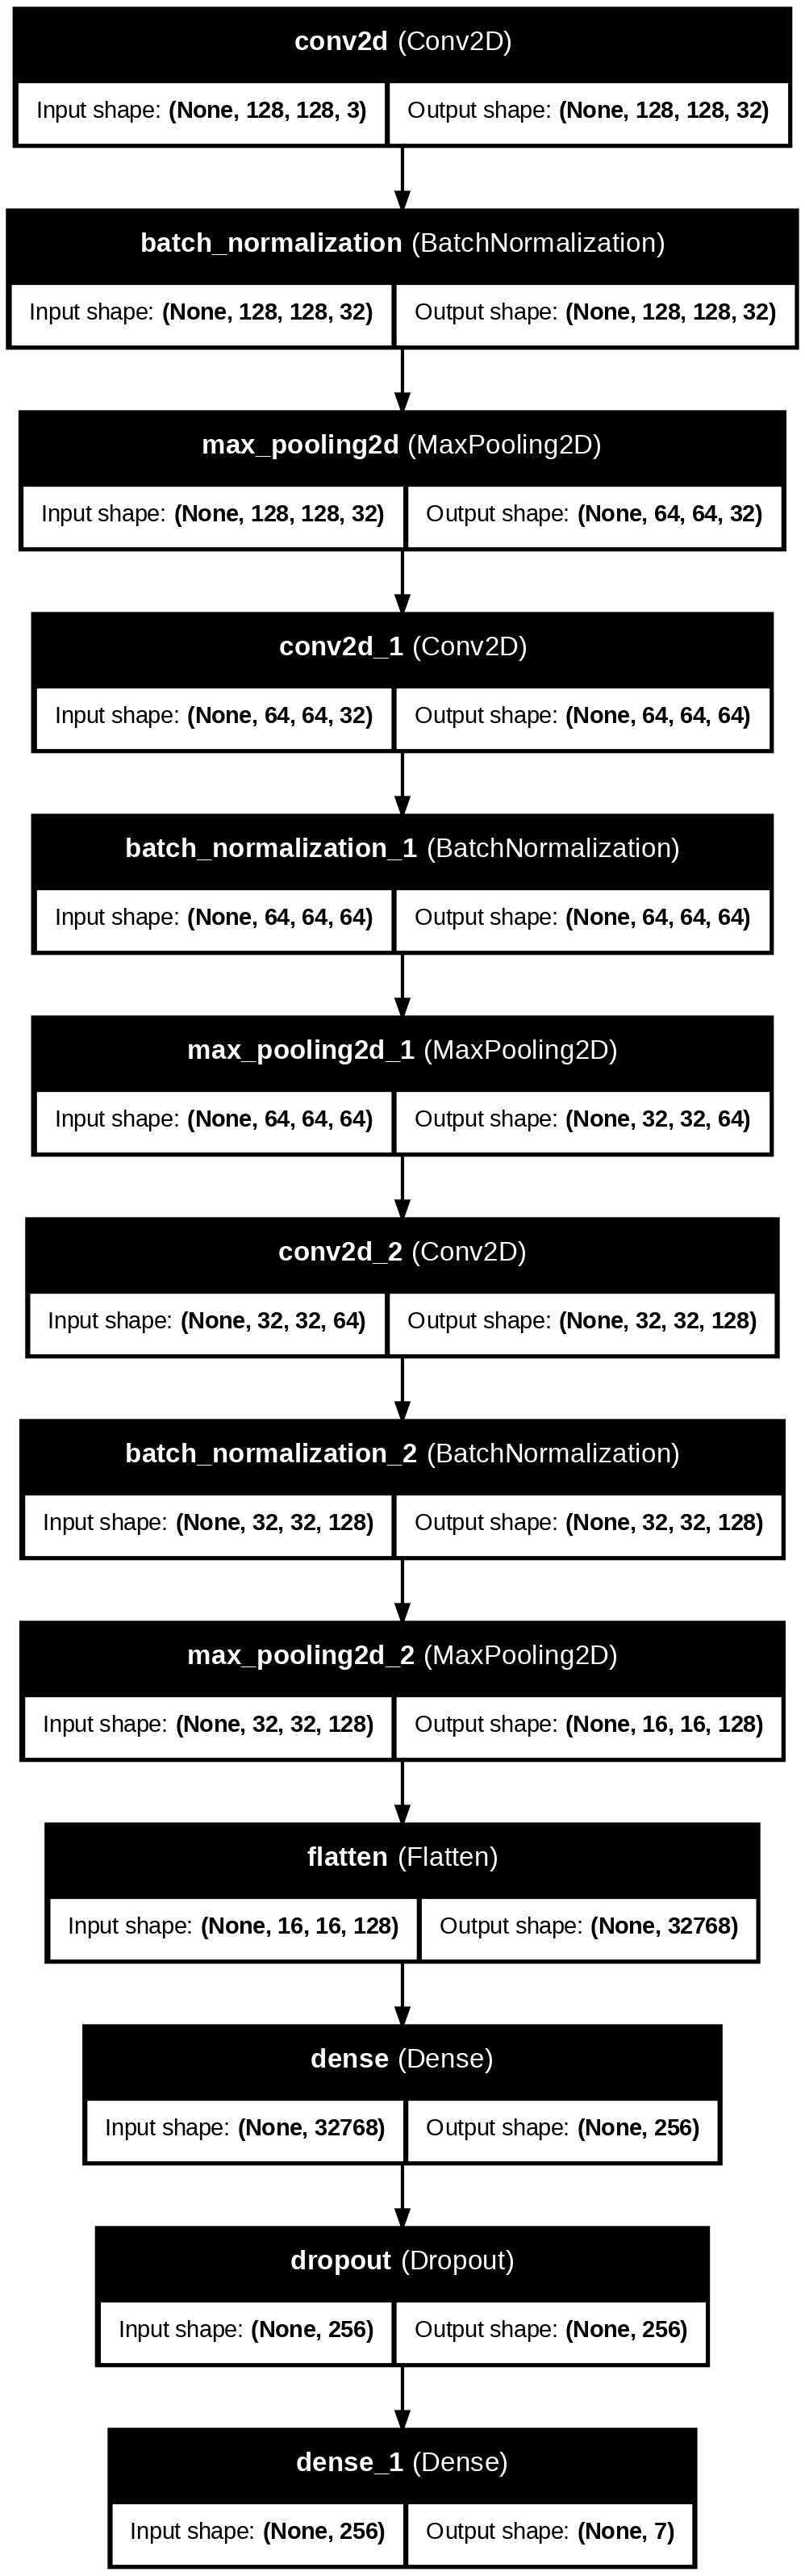

In [26]:
# CNN ARCHITECTURE DIAGRAM

plot_model(
    cnn_model,
    to_file='cnn_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=150
)

print("Architecture diagram saved as 'cnn_architecture.png'")
display(IPImage('cnn_architecture.png'))

# *11. CNN Model Training***
The CNN is trained using **augmented batches** from the training set, with validation monitored at every epoch.

In [27]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("EarlyStopping configured (patience=5, restore_best_weights=True)")

EarlyStopping configured (patience=5, restore_best_weights=True)


In [28]:
# EXPERIMENTAL SETUP TABLE

exp_df = pd.DataFrame({
    "Component" : [
        "Hardware", "Platform", "Python", "TensorFlow",
        "Epochs (max)", "Batch Size", "Learning Rate", "Optimizer", "Early Stopping"
    ],
    "Value" : [
        "GPU (Kaggle / CPU fallback)",
        "Kaggle Notebook",
        sys.version.split()[0],
        tf.__version__,
        20, 32, 0.001, "Adam", "Yes (patience=5)"
    ]
})
print("Experimental Setup:")
display(exp_df)

Experimental Setup:


,Component,Value
0,Hardware,GPU (Kaggle / CPU fallback)
1,Platform,Kaggle Notebook
2,Python,3.12.13
3,TensorFlow,2.19.0
4,Epochs (max),20
5,Batch Size,32
6,Learning Rate,0.001
7,Optimizer,Adam
8,Early Stopping,Yes (patience=5)


In [29]:
# TRAIN CNN MODEL

cnn_history = cnn_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[early_stop],
    verbose=1
)

print("\n CNN training complete.")

# Save the trained model
cnn_model.save('cnn_model.keras')
print("CNN model saved as 'cnn_model.keras'")

Epoch 1/20


I0000 00:00:1783103860.548199     152 service.cc:152] XLA service 0x7fb698006c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783103860.548241     152 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1783103860.548246     152 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1783103861.101483     152 cuda_dnn.cc:529] Loaded cuDNN version 91002


  3/106 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.1597 - loss: 9.6116 

I0000 00:00:1783103865.984323     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


106/106 ━━━━━━━━━━━━━━━━━━━━ 25s 161ms/step - accuracy: 0.3558 - loss: 3.8294 - val_accuracy: 0.1583 - val_loss: 12.1503
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.4088 - loss: 1.5848 - val_accuracy: 0.3444 - val_loss: 3.2324
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.4615 - loss: 1.4246 - val_accuracy: 0.6028 - val_loss: 1.1970
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.5305 - loss: 1.2645 - val_accuracy: 0.3083 - val_loss: 6.2882
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.5281 - loss: 1.2644 - val_accuracy: 0.6000 - val_loss: 1.0504
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 115ms/step - accuracy: 0.5534 - loss: 1.1774 - val_accuracy: 0.4528 - val_loss: 1.2591
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.5790 - loss: 1.0680 - val_accuracy: 0.4667 - val_loss: 2.6776
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.5989 - loss: 1.0351 - va

In [59]:
print("Model Built:", cnn_model.built)
print("Model Inputs:", cnn_model.inputs)
print("Model Outputs:", cnn_model.outputs)

for layer in cnn_model.layers:
    print(layer.name)

Model Built: True
Model Inputs: [<KerasTensor shape=(None, 128, 128, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor>]
Model Outputs: [<KerasTensor shape=(None, 7), dtype=float32, sparse=False, ragged=False, name=keras_tensor_91>]
conv2d
batch_normalization
max_pooling2d
conv2d_1
batch_normalization_1
max_pooling2d_1
conv2d_2
batch_normalization_2
max_pooling2d_2
flatten
dense
dropout
dense_1


# *12. CNN Model Evaluation***

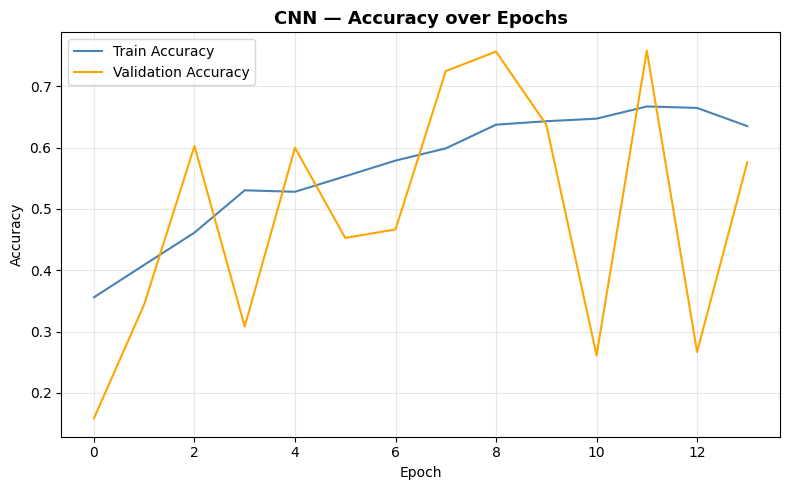

Accuracy curve saved as 'cnn_accuracy_curve.png'


In [30]:
#CNN TRAINING CURVES — ACCURACY

plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title("CNN — Accuracy over Epochs", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_accuracy_curve.png", dpi=150)
plt.show()
print("Accuracy curve saved as 'cnn_accuracy_curve.png'")

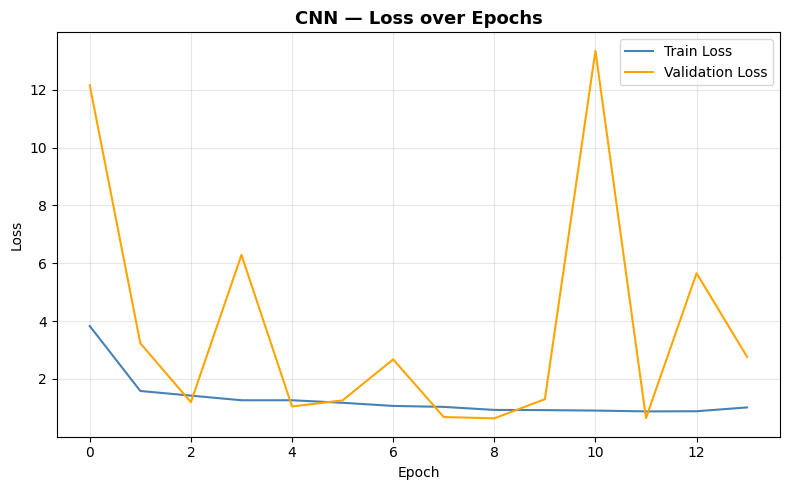

Loss curve saved as 'cnn_loss_curve.png'


In [31]:
# CNN TRAINING CURVES — LOSS

plt.figure(figsize=(8, 5))
plt.plot(cnn_history.history['loss'],     label='Train Loss',      color='steelblue')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss', color='orange')
plt.title("CNN — Loss over Epochs", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("cnn_loss_curve.png", dpi=150)
plt.show()
print("Loss curve saved as 'cnn_loss_curve.png'")

In [32]:
cnn_test_acc, cnn_test_loss = cnn_model.evaluate(X_test, y_test, verbose=0)

print(f" CNN Test Results:")
print(f"   Test Accuracy : {cnn_test_acc:.4f}  ({cnn_test_acc*100:.2f}%)")
print(f"   Test Loss     : {cnn_test_loss:.4f}")

 CNN Test Results:
   Test Accuracy : 0.6136  (61.36%)
   Test Loss     : 0.7587


In [33]:
#CNN PREDICTIONS

cnn_pred_prob = cnn_model.predict(X_test, verbose=0)
cnn_pred      = np.argmax(cnn_pred_prob, axis=1)

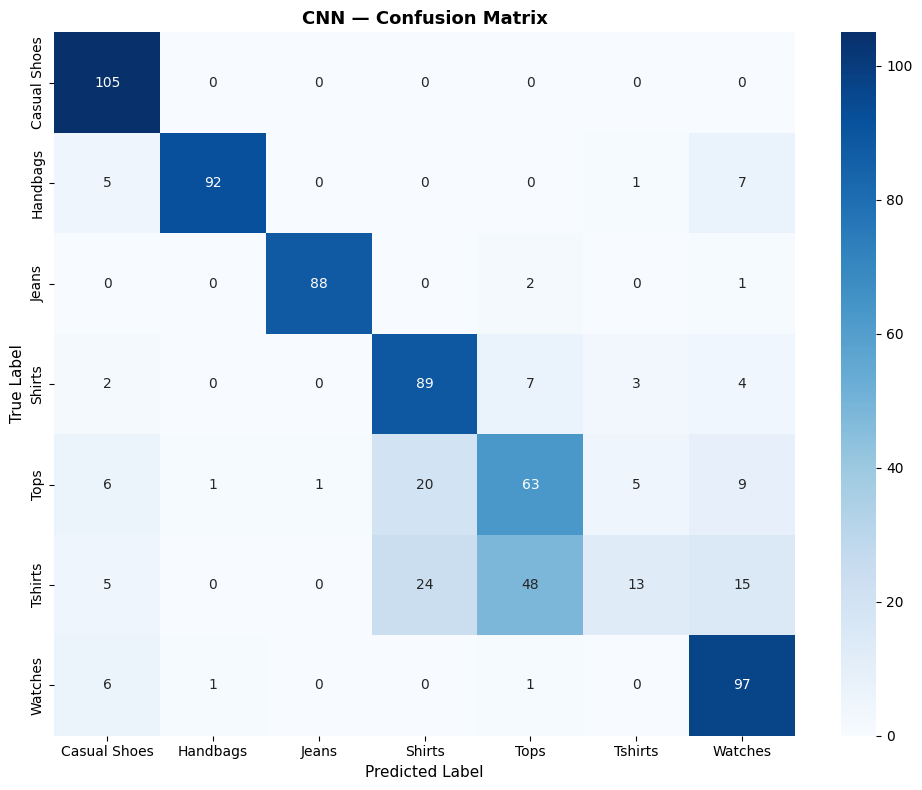

Confusion matrix saved as 'cnn_confusion_matrix.png'


In [34]:
# CNN CONFUSION MATRIX

cnn_cm = confusion_matrix(y_test, cnn_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cnn_cm,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("CNN — Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150)
plt.show()
print("Confusion matrix saved as 'cnn_confusion_matrix.png'")

In [35]:
# CNN CLASSIFICATION REPORT

print("CNN — Classification Report")
print("=" * 60)
print(classification_report(y_test, cnn_pred, target_names=le.classes_))

# Compute macro averages for comparison table later
cnn_precision, cnn_recall, cnn_f1, _ = precision_recall_fscore_support(
    y_test, cnn_pred, average='weighted'
)

print(f"Weighted Precision : {cnn_precision:.4f}")
print(f"Weighted Recall    : {cnn_recall:.4f}")
print(f"Weighted F1-Score  : {cnn_f1:.4f}")

CNN — Classification Report
              precision    recall  f1-score   support

Casual Shoes       0.81      1.00      0.90       105
    Handbags       0.98      0.88      0.92       105
       Jeans       0.99      0.97      0.98        91
      Shirts       0.67      0.85      0.75       105
        Tops       0.52      0.60      0.56       105
     Tshirts       0.59      0.12      0.20       105
     Watches       0.73      0.92      0.82       105

    accuracy                           0.76       721
   macro avg       0.76      0.76      0.73       721
weighted avg       0.75      0.76      0.73       721

Weighted Precision : 0.7514
Weighted Recall    : 0.7587
Weighted F1-Score  : 0.7274


# *13. MobileNetV2 Transfer Learning Model***

In [36]:
# BUILD MOBILENETV2 TRANSFER LEARNING MODEL

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128, 128, 3)
)

# Freeze all base model layers
base_model.trainable = False

print(f" MobileNetV2 base loaded.")
print(f"   Trainable layers : {sum(1 for l in base_model.layers if l.trainable)}")
print(f"   Frozen layers    : {sum(1 for l in base_model.layers if not l.trainable)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
 MobileNetV2 base loaded.
   Trainable layers : 0
   Frozen layers    : 154


In [37]:
#ADD CUSTOM CLASSIFICATION HEAD

x      = GlobalAveragePooling2D()(base_model.output)
x      = Dense(128, activation='relu')(x)
x      = Dropout(0.4)(x)
output = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=output, name="MobileNetV2_TL")

tl_model.compile(
    optimizer=Adam(learning_rate=0.0001),   # lower LR for fine-tuning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 transfer learning model compiled.")
tl_model.summary()


MobileNetV2 transfer learning model compiled.


Model: "MobileNetV2_TL"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# *14. MobileNetV2 Training & Evaluation***

In [38]:
tl_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("🚀 Starting MobileNetV2 training...")

tl_history = tl_model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=[tl_early_stop],
    verbose=1
)

print("\n MobileNetV2 training complete.")

tl_model.save('mobilenetv2_model.keras')
print("MobileNetV2 model saved as 'mobilenetv2_model.keras'")

🚀 Starting MobileNetV2 training...
Epoch 1/20


2026-07-03 18:41:02.600765: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 18:41:02.737848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 61/106 ━━━━━━━━━━━━━━━━━━━━ 4s 107ms/step - accuracy: 0.2746 - loss: 2.0685

2026-07-03 18:41:19.856354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 18:41:19.996064: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.3787 - loss: 1.7775

2026-07-03 18:41:39.602360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 18:41:39.755646: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 18:41:39.891523: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


106/106 ━━━━━━━━━━━━━━━━━━━━ 53s 350ms/step - accuracy: 0.5784 - loss: 1.2288 - val_accuracy: 0.8556 - val_loss: 0.4815
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.8411 - loss: 0.4861 - val_accuracy: 0.8931 - val_loss: 0.3246
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.8857 - loss: 0.3471 - val_accuracy: 0.9083 - val_loss: 0.2681
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.9063 - loss: 0.3055 - val_accuracy: 0.9194 - val_loss: 0.2416
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 0.9113 - loss: 0.2649 - val_accuracy: 0.9292 - val_loss: 0.2196
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 111ms/step - accuracy: 0.9170 - loss: 0.2414 - val_accuracy: 0.9125 - val_loss: 0.2240
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 112ms/step - accuracy: 0.9217 - loss: 0.2283 - val_accuracy: 0.9250 - val_loss: 0.2123
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - accuracy: 0.9286 - loss: 0.2146 - val

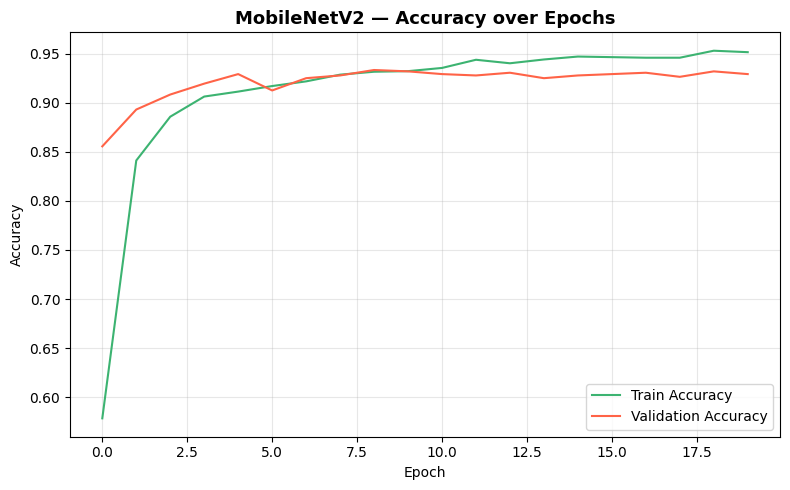

MobileNetV2 accuracy curve saved as 'tl_accuracy_curve.png'


In [39]:
plt.figure(figsize=(8, 5))
plt.plot(tl_history.history['accuracy'],     label='Train Accuracy',      color='mediumseagreen')
plt.plot(tl_history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
plt.title("MobileNetV2 — Accuracy over Epochs", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tl_accuracy_curve.png", dpi=150)
plt.show()
print("MobileNetV2 accuracy curve saved as 'tl_accuracy_curve.png'")

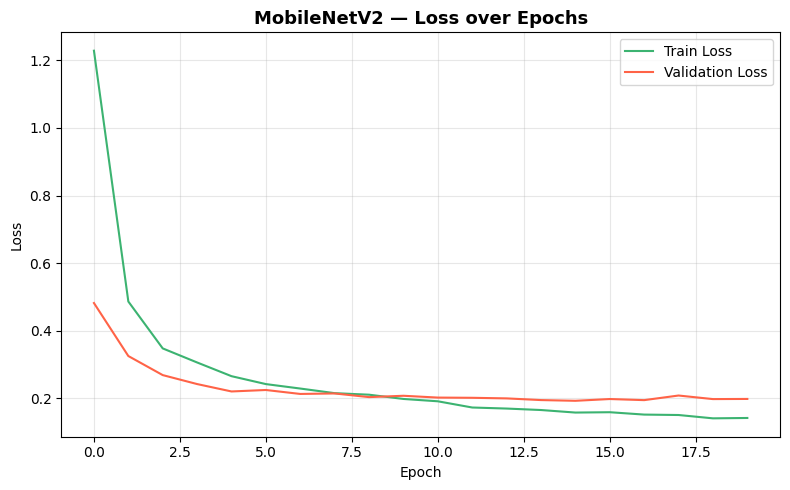

MobileNetV2 loss curve saved as 'tl_loss_curve.png'


In [40]:
plt.figure(figsize=(8, 5))
plt.plot(tl_history.history['loss'],     label='Train Loss',      color='mediumseagreen')
plt.plot(tl_history.history['val_loss'], label='Validation Loss', color='tomato')
plt.title("MobileNetV2 — Loss over Epochs", fontsize=13, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("tl_loss_curve.png", dpi=150)
plt.show()
print("MobileNetV2 loss curve saved as 'tl_loss_curve.png'")

In [41]:
tl_test_loss, tl_test_acc = tl_model.evaluate(X_test, y_test, verbose=0)

print(f" MobileNetV2 Test Results:")
print(f"   Test Accuracy : {tl_test_acc:.4f}  ({tl_test_acc*100:.2f}%)")
print(f"   Test Loss     : {tl_test_loss:.4f}")

2026-07-03 18:45:35.967677: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-03 18:45:36.104366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 MobileNetV2 Test Results:
   Test Accuracy : 0.9473  (94.73%)
   Test Loss     : 0.1514


In [42]:
tl_pred_prob = tl_model.predict(X_test, verbose=0)
tl_pred      = np.argmax(tl_pred_prob, axis=1)

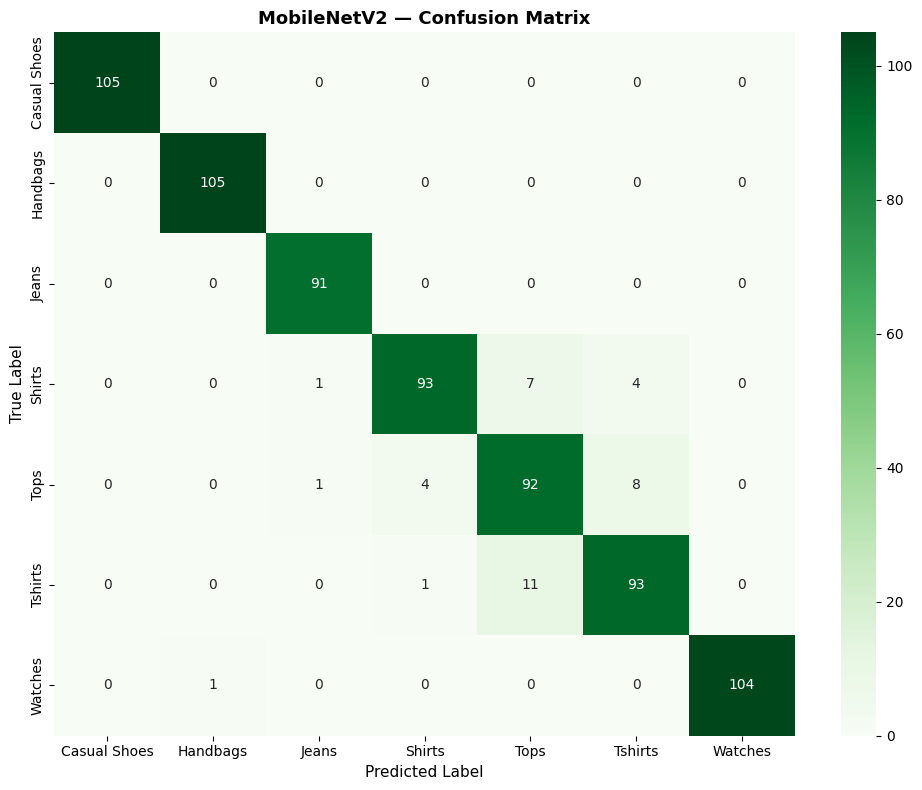

 MobileNetV2 confusion matrix saved as 'tl_confusion_matrix.png'


In [43]:
# MOBILENETV2 CONFUSION MATRIX

tl_cm = confusion_matrix(y_test, tl_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    tl_cm,
    annot=True, fmt='d', cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title("MobileNetV2 — Confusion Matrix", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig("tl_confusion_matrix.png", dpi=150)
plt.show()
print(" MobileNetV2 confusion matrix saved as 'tl_confusion_matrix.png'")

In [44]:
# MOBILENETV2 CLASSIFICATION REPORT

print("MobileNetV2 — Classification Report")
print("=" * 60)
print(classification_report(y_test, tl_pred, target_names=le.classes_))

# Compute weighted averages for comparison table
tl_precision, tl_recall, tl_f1, _ = precision_recall_fscore_support(
    y_test, tl_pred, average='weighted'
)

print(f"Weighted Precision : {tl_precision:.4f}")
print(f"Weighted Recall    : {tl_recall:.4f}")
print(f"Weighted F1-Score  : {tl_f1:.4f}")

MobileNetV2 — Classification Report
              precision    recall  f1-score   support

Casual Shoes       1.00      1.00      1.00       105
    Handbags       0.99      1.00      1.00       105
       Jeans       0.98      1.00      0.99        91
      Shirts       0.95      0.89      0.92       105
        Tops       0.84      0.88      0.86       105
     Tshirts       0.89      0.89      0.89       105
     Watches       1.00      0.99      1.00       105

    accuracy                           0.95       721
   macro avg       0.95      0.95      0.95       721
weighted avg       0.95      0.95      0.95       721

Weighted Precision : 0.9480
Weighted Recall    : 0.9473
Weighted F1-Score  : 0.9474


# *15. Model Comparison***

In [45]:
comparison_df = pd.DataFrame({
    "Metric" : ["Test Accuracy", "Test Loss", "Weighted Precision",
                "Weighted Recall", "Weighted F1-Score"],
    "Custom CNN" : [
        round(cnn_test_acc, 4),
        round(cnn_test_loss, 4),
        round(cnn_precision, 4),
        round(cnn_recall, 4),
        round(cnn_f1, 4)
    ],
    "MobileNetV2 (Transfer Learning)" : [
        round(tl_test_acc, 4),
        round(tl_test_loss, 4),
        round(tl_precision, 4),
        round(tl_recall, 4),
        round(tl_f1, 4)
    ]
})

print("Model Comparison Table:")
display(comparison_df)

Model Comparison Table:


,Metric,Custom CNN,MobileNetV2 (Transfer Learning)
0,Test Accuracy,0.6136,0.9473
1,Test Loss,0.7587,0.1514
2,Weighted Precision,0.7514,0.9480
3,Weighted Recall,0.7587,0.9473
4,Weighted F1-Score,0.7274,0.9474


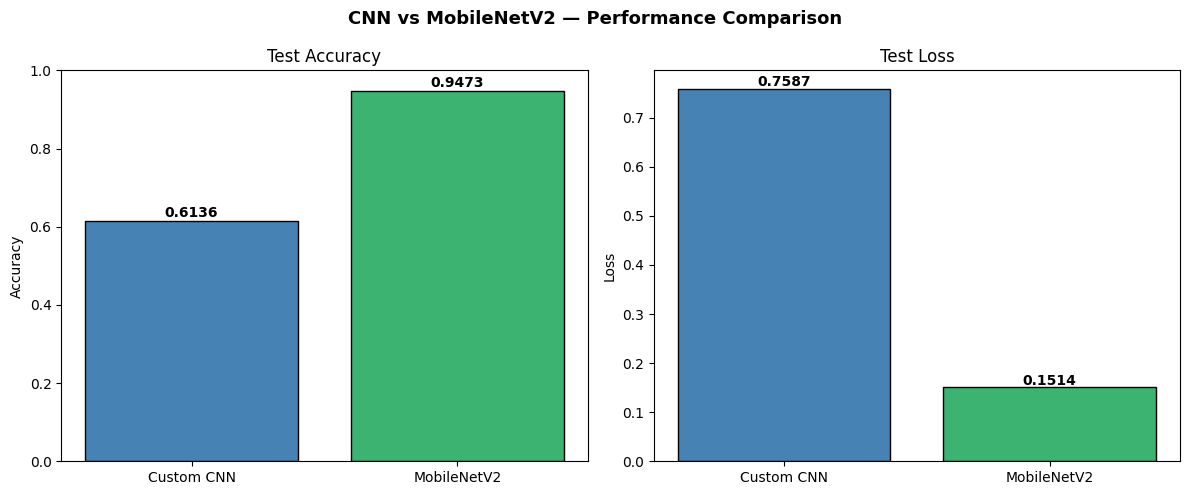

Comparison chart saved as 'model_comparison.png'


In [46]:
# COMPARISON BAR CHART — ACCURACY & LOSS

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("CNN vs MobileNetV2 — Performance Comparison",
             fontsize=13, fontweight='bold')

models_labels = ["Custom CNN", "MobileNetV2"]
colors        = ["steelblue", "mediumseagreen"]

# Accuracy
axes[0].bar(models_labels, [cnn_test_acc, tl_test_acc], color=colors, edgecolor='black')
axes[0].set_title("Test Accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1)
for i, v in enumerate([cnn_test_acc, tl_test_acc]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# Loss
axes[1].bar(models_labels, [cnn_test_loss, tl_test_loss], color=colors, edgecolor='black')
axes[1].set_title("Test Loss")
axes[1].set_ylabel("Loss")
for i, v in enumerate([cnn_test_loss, tl_test_loss]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()
print("Comparison chart saved as 'model_comparison.png'")

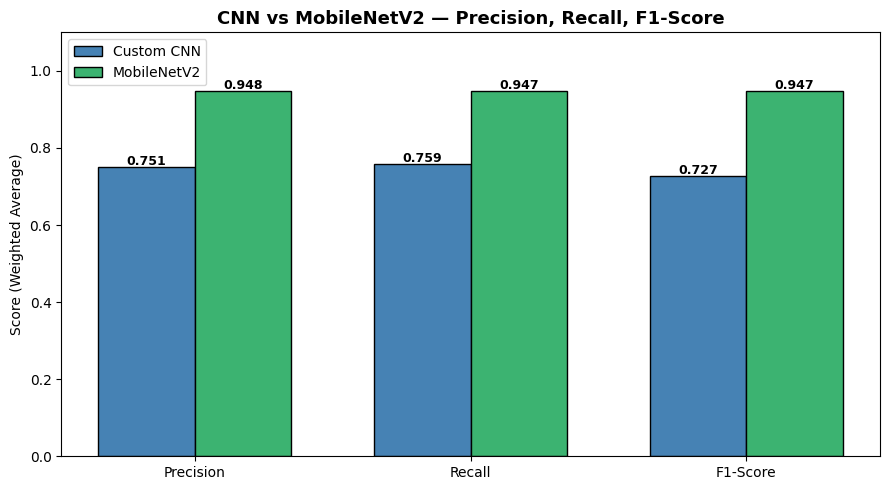

Metric comparison chart saved as 'metric_comparison.png'


In [47]:
# COMPARISON BAR CHART — F1, PRECISION, RECALL

metrics      = ["Precision", "Recall", "F1-Score"]
cnn_scores   = [cnn_precision, cnn_recall, cnn_f1]
tl_scores    = [tl_precision,  tl_recall,  tl_f1]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, cnn_scores, width, label='Custom CNN',   color='steelblue',      edgecolor='black')
bars2 = ax.bar(x + width/2, tl_scores,  width, label='MobileNetV2', color='mediumseagreen', edgecolor='black')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f"{bar.get_height():.3f}",
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score (Weighted Average)")
ax.set_title("CNN vs MobileNetV2 — Precision, Recall, F1-Score",
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()
print("Metric comparison chart saved as 'metric_comparison.png'")

# *16. Grad-CAM — Gradient-weighted Class Activation Mapping***

In [73]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

last_conv_layer_name = "conv2d_2"

print("Using layer:", last_conv_layer_name)

Using layer: conv2d_2


In [74]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # IMPORTANT FIX
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), pred_index.numpy()

In [76]:
def overlay_heatmap(img, heatmap, alpha=0.4):

    heatmap = cv2.resize(heatmap, (128, 128))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    img = np.uint8(img * 255)

    return cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)

In [77]:
# ============================================================
# CELL 61: Grad-CAM Grid Visualization
# ============================================================

num_images = 6
indices = np.random.choice(len(X_test), num_images, replace=False)

plt.figure(figsize=(16, 12))

for i, idx in enumerate(indices):

    img = X_test[idx]
    img_input = np.expand_dims(img, axis=0)

    preds = cnn_model.predict(img_input, verbose=0)
    pred_class = np.argmax(preds)

    heatmap, _ = make_gradcam_heatmap(img_input, cnn_model, "conv2d_2")
    overlay = overlay_heatmap(img, heatmap)

    # Original
    plt.subplot(num_images, 3, 3*i + 1)
    plt.imshow(img)
    plt.title("Original")
    plt.axis("off")

    # Heatmap
    plt.subplot(num_images, 3, 3*i + 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Heatmap")
    plt.axis("off")

    # Overlay
    plt.subplot(num_images, 3, 3*i + 3)
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.title(f"Pred: {TOP_CLASSES[pred_class]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

AttributeError: The layer Custom_CNN has never been called and thus has no defined output.

<Figure size 1600x1200 with 0 Axes>